In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict, cross_validate, KFold
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_curve, auc, confusion_matrix, make_scorer,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [114]:
url = pd.read_csv('../data/raw/7.4.3.2_mushroom_competition_test_data.csv')
path = '/Users/kubrademirhan/Documents/mushroom_comp_test_data/data/raw/7.4.3.2_mushroom_competition_test_data.csv'

data_test = pd.read_csv(path).set_index('Id')
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1625 entries, 5165 to 6821
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   cap.shape               1625 non-null   object
 1   cap.color               1625 non-null   object
 2   stalk.color.above.ring  1625 non-null   object
 3   stalk.color.below.ring  1625 non-null   object
 4   bruises                 1625 non-null   bool  
 5   population              1625 non-null   object
dtypes: bool(1), object(5)
memory usage: 77.8+ KB


In [115]:
ulr = pd.read_csv('../data/raw/7.4.3.1_mushroom_competition_train_data.csv')
path = ('/Users/kubrademirhan/Documents/mushroom_comp_test_data/data/raw/7.4.3.1_mushroom_competition_train_data.csv')

data_train = pd.read_csv(path)
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6499 entries, 0 to 6498
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   cap.shape               6499 non-null   object
 1   cap.color               6499 non-null   object
 2   bruises                 6499 non-null   bool  
 3   stalk.color.above.ring  6499 non-null   object
 4   stalk.color.below.ring  6499 non-null   object
 5   population              6499 non-null   object
 6   Id                      6499 non-null   int64 
 7   poisonous               6499 non-null   int64 
dtypes: bool(1), int64(2), object(5)
memory usage: 361.9+ KB


In [116]:
# Define X and y
X = data_train.drop(['poisonous', 'Id'], axis=1)
y = data_train.poisonous

In [117]:
X

,cap.shape,cap.color,bruises,stalk.color.above.ring,stalk.color.below.ring,population
0,k,e,False,w,w,v
1,f,e,True,p,w,y
2,b,w,False,w,w,s
3,k,g,False,w,w,n
4,f,n,True,p,g,v
...,...,...,...,...,...,...
6494,f,g,False,b,b,v
6495,k,e,False,p,p,v
6496,f,g,False,n,b,y
6497,f,n,True,w,w,s


In [118]:
y

0       1
1       0
2       0
3       0
4       0
       ..
6494    1
6495    1
6496    1
6497    0
6498    1
Name: poisonous, Length: 6499, dtype: int64

In [119]:
# Train-Test-Split
X_test, X_train, y_test,y_train = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [120]:
# Build Pipelines
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ('model', LogisticRegression(max_iter=1000))
])

In [121]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore')),
                ('model', LogisticRegression(max_iter=1000))])

In [123]:
# Get Probability
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_prob

array([0.85232401, 0.20389469, 0.02550723, ..., 0.08505039, 0.01123582,
       0.00797297])

In [124]:
# Search for Hard Constraint Thresholds

thresholds = np.sort(np.unique(y_prob))

best_threshold = None
max_edible = 0

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    if fn == 0:
        if tn > max_edible:
            max_edible = tn
            best_threshold = t

print('Best Threshold (FN = 0):', best_threshold)
print('Edible Mushrooms you can safely eat:', max_edible)

Best Threshold (FN = 0): 0.012424405905255825
Edible Mushrooms you can safely eat: 553


In [125]:
# Final Confusion Matrix
final_preds = (y_prob >= best_threshold).astype(int)
final_preds

array([1, 1, 1, ..., 1, 0, 0])

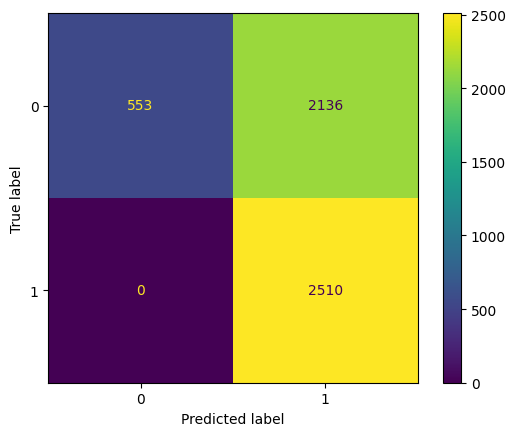

In [126]:
ConfusionMatrixDisplay.from_predictions(y_test, final_preds)

In [128]:
print(f'''Interpretation: We can safly eat {max_edible} mushrooms while guaranteeing that no poisonous mushroom is classified as edible.''')

Interpretation: We can safly eat 553 mushrooms while guaranteeing that no poisonous mushroom is classified as edible.
